In [152]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

In [153]:
df = pd.read_csv('data.csv', encoding='latin1')

In [154]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [155]:
df.dropna(inplace=True)

In [156]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm.reset_index()

In [157]:
rfm

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,2,0.00
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
...,...,...,...,...
4367,18280.0,278,1,180.60
4368,18281.0,181,1,80.82
4369,18282.0,8,3,176.60
4370,18283.0,4,16,2094.88


In [158]:
"""
Loyalty type from non-loyal to most loyal:
- Champions: Recent, frequent, and high spending customers.
- Loyal Customers: Frequent and high spending customers, but not recent.
- Potential Loyalists: Recent and high spending customers, but not frequent.
- New Customers: Recent customers who haven't had the chance to become loyal yet.
- Promising: Recent customers with moderate spending.
- Need Attention: Customers who haven't been recent but have moderate spending.
- About To Sleep: Customers who haven't been recent and have low spending.
- At Risk: Customers who haven't been recent and have moderate spending.
- Can't Lose Them: Customers who haven't been recent but have high spending.
"""
kmeans = KMeans(n_clusters=4, random_state=42)
X = rfm[['Recency', 'Frequency', 'Monetary']]
rfm['Cluster'] = kmeans.fit_predict(X)

In [159]:
rfm

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,2,0.00,0
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,0
...,...,...,...,...,...
4367,18280.0,278,1,180.60,0
4368,18281.0,181,1,80.82,0
4369,18282.0,8,3,176.60,0
4370,18283.0,4,16,2094.88,0


In [160]:
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,92.840841,4.570109,1347.622983
1,3.666667,64.666667,241136.560000
2,13.138889,50.722222,35694.129167
3,9.500000,96.500000,114451.897500


In [161]:
cluster_names = {
    0: 'Bronze',
    2: 'Silver',
    3: 'Gold',
    1: 'Platinum'
}

rfm['ClusterName'] = rfm['Cluster'].map(cluster_names)

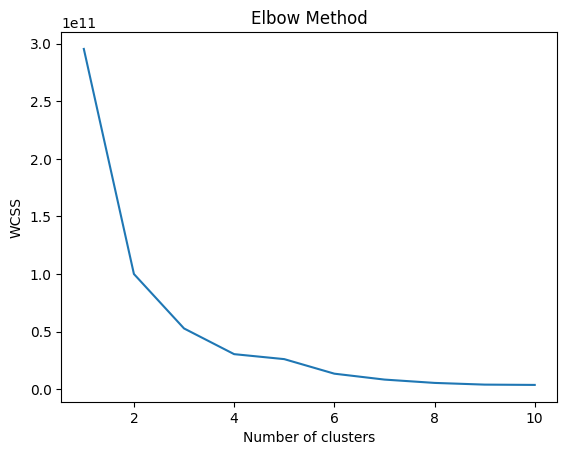

In [162]:
"""
Elbow method: Plot the within-cluster sum of squares (WCSS) against the number of clusters to find the "elbow" point where the rate of decrease sharply changes.
"""
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
import matplotlib.pyplot as plt
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [163]:
import plotly.express as px

fig = px.scatter_3d(
    rfm,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='ClusterName',
    title='RFM Customer Segments'
)

fig.update_layout(
    scene=dict(
        xaxis_title='Recency (days)',
        yaxis_title='Frequency',
        zaxis_title='Monetary Value'
    )
)

fig.write_html("rfm_clusters_3d.html", include_plotlyjs="cdn")
print("Saved: rfm_clusters_3d.html")

Saved: rfm_clusters_3d.html
